# 🌎🕯🗺 Gaia Positions and Photometry 

Often you need to know the magnitude of a star. Fortunately, the space-based [Gaia](https://gea.esac.esa.int/archive/) survey has observed the entire sky with incredible precision; basically any star you can see with a moderate ground-based telescope has already been observed by Gaia. Common reasons you might need to download stars from Gaia would be to locate where to put apertures in an image or to use a star you observed as a flux calibrator; this page demonstrates two little tools that might be helpful for those purposes!

## Downloading Gaia Data 💾

To get a table of positions and photometry, we can use the `get_gaia` function. This is a wrapper to `astroquery` and the fabulous Gaia archive, designed to be quick and easy to use. 

In [54]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from thefriendlystars import get_gaia

To download some stars, specify a center and a radius, and let the function download data within that radius of that location. This will both download the star magnitudes directly measured with Gaia (`G_gaia`, `BP_gaia`, `RP_gaia`) and use color transformations to estimate the magnitudes in other common filters (`g_sloan`, `r_sloan`, `i_sloan`, `V_johnsoncousins`, `R_johnsoncousins`, `I_johnsoncousins`). With the results, you should have a decent estimate of the brightness of any star you want!

In [55]:
random_center = SkyCoord(ra=123.45*u.deg, dec=67.89*u.deg)
random_radius = 10*u.arcmin
random_stars = get_gaia(random_center, radius=random_radius)

INFO: Query finished. [astroquery.utils.tap.core]


In [56]:
random_stars

ra,dec,G_gaia_mag,RP_gaia_mag,BP_gaia_mag,parallax,pmra,pmdec,distance_from_center,r_sloan_mag,i_sloan_mag,g_sloan_mag,V_johnsoncousins_mag,R_johnsoncousins_mag,I_johnsoncousins_mag
deg,deg,mag,mag,mag,mas,mas / yr,mas / yr,deg,mag,mag,mag,mag,mag,mag
float64,float64,float32,float32,float32,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32
123.46358938838631,67.88971682015931,20.226247787475586,18.9457950592041,21.279850006103516,2.4612139436267366,-1.5109944465762766,-0.9993581676749135,0.005120868239370292,20.55800437927246,19.56468391418457,22.2702579498291,21.203420639038086,20.067562103271484,18.998441696166992
123.43892343048769,67.8956124547175,21.295581817626953,20.320524215698242,21.499958038330078,———,———,———,0.0069969087815645375,21.252859115600586,20.969985961914062,22.02094841003418,21.562204360961914,21.033828735351562,20.53368377685547
123.45645641263971,67.88125775716301,19.707828521728516,18.38322639465332,20.979854583740234,3.0573802467382465,11.880533201188976,-7.393675877038789,0.009067637449834529,20.247432708740234,19.007596969604492,22.09683609008789,20.911039352416992,19.622631072998047,18.409908294677734
123.41929334070166,67.89178083196823,16.634456634521484,15.85244083404541,17.314313888549805,1.2050908672850105,-5.567979326150691,-12.077443510338655,0.011695937379324848,16.615947723388672,16.201696395874023,17.64654541015625,17.0322265625,16.364782333374023,15.734864234924316
123.47577477788626,67.89700846015798,19.78288459777832,18.77142333984375,20.774452209472656,0.976072598519347,-0.6670059327289899,-5.061786742454724,0.01196910051885525,19.925397872924805,19.189992904663086,21.412328720092773,20.509124755859375,19.557979583740234,18.662395477294922
123.49999720110058,67.88908128599442,20.955039978027344,19.92739486694336,21.314929962158203,———,———,———,0.018839214907547107,20.92664909362793,20.54891586303711,21.889101028442383,21.31561279296875,20.68536949157715,20.090198516845703
123.46783490647054,67.90936044690477,18.45643424987793,17.441452026367188,19.556238174438477,1.1080267906264099,6.302811485122927,2.3875680980172596,0.020495447027755437,18.654342651367188,17.837873458862305,20.223045349121094,19.263147354125977,18.25058937072754,17.297353744506836
123.43623401557618,67.91233256108121,14.924246788024902,14.474855422973633,15.206657409667969,0.6235000607444191,-2.598814995200761,-0.8877672011204992,0.022931369613180104,14.90665340423584,14.801634788513184,15.253921508789062,15.039621353149414,14.719002723693848,14.412050247192383


Columns from this table can be extracted via their names.

In [57]:
random_stars['ra']

<MaskedQuantity [123.46358939, 123.43892343, 123.45645641, 123.41929334,
                 123.47577478, 123.4999972 , 123.46783491, 123.43623402,
                 123.4940524 , 123.51786989, 123.46019585, 123.43114412,
                 123.39442485, 123.37732412, 123.39197775, 123.49029517,
                 123.4566544 , 123.44320084, 123.39509667, 123.43751646,
                 123.41420486, 123.39373257, 123.39334666, 123.34592909,
                 123.3450379 , 123.50901141, 123.43364519, 123.34502666,
                 123.56654593, 123.46620021, 123.42462747, 123.53572837,
                 123.50642959, 123.54465586, 123.39141454, 123.5153039 ,
                 123.32894621, 123.47477858, 123.42570387, 123.36396303,
                 123.47374486, 123.59249224, 123.32897279, 123.46496253,
                 123.57328541, 123.30034153, 123.55107529, 123.50837125,
                 123.30384553, 123.55633068, 123.57987316, 123.54349965,
                 123.56052627, 123.50922604, 123.53

We can also specify the center by using a star or object's common catalog name.

In [58]:
some_stars = get_gaia('GJ 1214')

INFO: Query finished. [astroquery.utils.tap.core]


In [59]:
some_stars

ra,dec,G_gaia_mag,RP_gaia_mag,BP_gaia_mag,parallax,pmra,pmdec,distance_from_center,r_sloan_mag,i_sloan_mag,g_sloan_mag,V_johnsoncousins_mag,R_johnsoncousins_mag,I_johnsoncousins_mag
deg,deg,mag,mag,mag,mas,mas / yr,mas / yr,deg,mag,mag,mag,mag,mag,mag
float64,float64,float32,float32,float32,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32
258.8314799887317,4.960575338342743,12.996782302856445,11.68291187286377,14.912440299987793,68.29864790496704,580.202152322342,-749.7132787585067,0.004213552668599534,14.281705856323242,12.260824203491211,16.261287689208984,14.842987060546875,13.164945602416992,11.584444046020508
258.82548059022554,4.959673415391515,19.814598083496094,18.7404842376709,20.92361831665039,-0.12201931576844059,0.7886772319541978,-5.90216430988526,0.005436667992000686,20.050561904907227,19.18158721923828,21.666542053222656,20.672658920288086,19.622066497802734,18.633102416992188
258.8303453443598,4.969318799593391,18.467039108276367,17.849897384643555,18.9268798828125,0.32598400597497745,-2.3171063464633663,-2.8002450271574886,0.0055955384177896455,18.423870086669922,18.184314727783203,19.095197677612305,18.692920684814453,18.213462829589844,17.75888442993164
258.8345934758168,4.965356067428126,19.528406143188477,18.817964553833008,20.048349380493164,0.9195919172227879,-0.13105104020166408,-2.780651379773647,0.005855234311897603,19.487468719482422,19.182281494140625,20.303503036499023,19.8166446685791,19.26363754272461,18.74053192138672
258.8260166383157,4.969221589104122,21.041614532470703,19.73952293395996,22.038986206054688,———,———,———,0.0060354235140618676,21.349946975708008,20.386186599731445,23.041173934936523,21.99078941345215,20.874629974365234,19.82403564453125
258.8331333378074,4.9586369446744065,17.20298957824707,16.52166175842285,17.653566360473633,0.31761288226776757,-2.6388754129907195,-1.8090458983625795,0.006755475541979879,17.1595516204834,16.897018432617188,17.88279151916504,17.450260162353516,16.944679260253906,16.46577262878418
258.8221023063075,4.964097257256533,18.891849517822266,18.464885711669922,19.212743759155273,-0.08964745632392115,-0.21041661007722506,-5.859332991385228,0.006772388702946496,18.87225341796875,18.761253356933594,19.234365463256836,19.011449813842773,18.68364715576172,18.37002944946289
258.8275448277946,4.956599989525407,18.19046974182129,18.28221321105957,18.134431838989258,0.128803443046689,-2.2870076084982003,-14.33279722520088,0.007435504306852188,18.35614585876465,18.585100173950195,17.99251365661621,18.210838317871094,18.253276824951172,18.281362533569336


## Visualizing Gaia Data 🎨

It'd be nice to be able to see this information in a way that's not just a giant table of data. Let's use the `plot_gaia` tool to plot one of the tables we've already downloaded. 

In [60]:
from thefriendlystars import plot_gaia

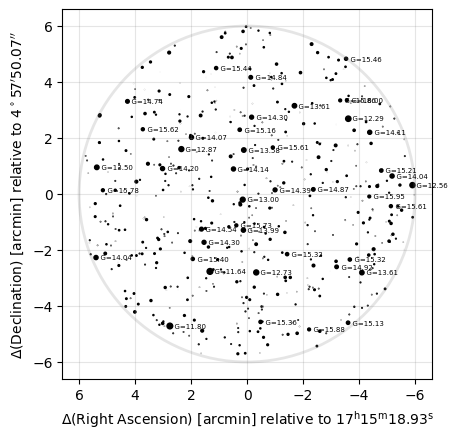

In [61]:
plot_gaia(some_stars)

In [62]:
table = some_stars

We can change options to modify the appearance of this finder chart, including changing which filter is used to set the relative sizes of the points. 

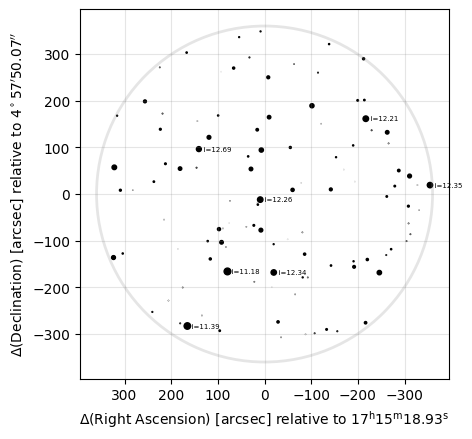

In [63]:
plot_gaia(some_stars, 
          filter='i_sloan',
          faintest_magnitude_to_show=17,
          faintest_magnitude_to_label=13,
          size_of_zero_magnitude=200,
          unit=u.arcsec)

With these tools, you can access a table of data and a quick visualization for any patch of the sky you care about!

INFO: Query finished. [astroquery.utils.tap.core]


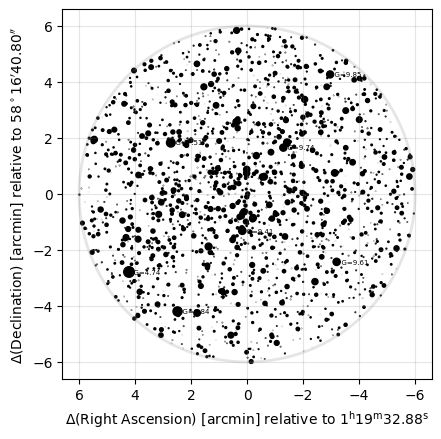

In [64]:
cluster_center = SkyCoord.from_name("NGC 457")
cluster_stars = get_gaia(cluster_center)
plot_gaia(cluster_stars, faintest_magnitude_to_label=10)